#2. Predicting Housing Prices: Develop a regression model to predict house prices based on features like location, size, and amenities.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AML_Lab/Housing_Price_Dataset_120_Records.csv')
df

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Furnished,Price
0,H001,Rural,1028,1,3,0,0,5,Yes,55.84
1,H002,Rural,2316,1,4,0,0,3,Yes,103.88
2,H003,Urban,1834,1,2,2,2,23,No,86.42
3,H004,Urban,1719,3,1,0,2,14,No,96.77
4,H005,Suburban,1118,2,3,0,0,13,Yes,63.94
...,...,...,...,...,...,...,...,...,...,...
115,H116,Rural,1624,3,4,1,0,20,Yes,72.72
116,H117,Suburban,2304,3,3,0,0,8,Yes,110.52
117,H118,Rural,2482,3,1,0,1,17,No,86.06
118,H119,Suburban,1171,4,4,0,1,12,No,88.73


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HouseID    120 non-null    object 
 1   Location   120 non-null    object 
 2   Area_sqft  120 non-null    int64  
 3   Bedrooms   120 non-null    int64  
 4   Bathrooms  120 non-null    int64  
 5   Balcony    120 non-null    int64  
 6   Parking    120 non-null    int64  
 7   Age_Years  120 non-null    int64  
 8   Furnished  120 non-null    object 
 9   Price      120 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 9.5+ KB


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Price,HouseID_H002,HouseID_H003,HouseID_H004,...,HouseID_H114,HouseID_H115,HouseID_H116,HouseID_H117,HouseID_H118,HouseID_H119,HouseID_H120,Location_Suburban,Location_Urban,Furnished_Yes
0,1028,1,3,0,0,5,55.84,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2316,1,4,0,0,3,103.88,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1834,1,2,2,2,23,86.42,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,1719,3,1,0,2,14,96.77,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,1118,2,3,0,0,13,63.94,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [ ]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (120, 128)
y shape: (120,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Training samples: 96
Testing samples: 24


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients
print("Intercept:", model.intercept_)


Intercept: 6.349154917416854


In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)


,Actual Price,Predicted Price
0,101.39,102.499220
1,66.90,66.587245
2,63.94,63.759214
3,60.96,60.872452
4,62.13,63.163208
5,58.67,59.805500
6,35.35,36.546967
7,66.31,66.151680
8,102.29,101.309692
9,63.55,63.012358


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 0.6558491106837855


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 0.6558491106837855


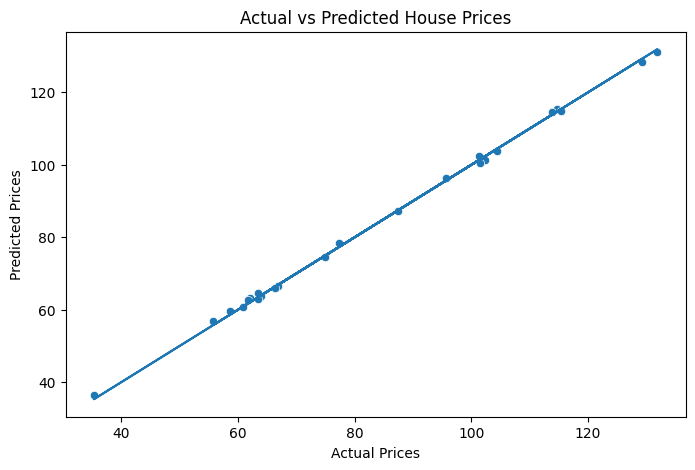

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot(y_test, y_test)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [ ]:
new_data = dict.fromkeys(X.columns, 0)

# Fill only meaningful values
new_data["Area_sqft"] = float(input("Enter Area_sqft: "))
new_data["Bedrooms"] = float(input("Enter Bedrooms: "))
new_data["Bathrooms"] = float(input("Enter Bathrooms: "))
new_data["Age_Years"] = float(input("Enter Age_Years: "))
new_data["Parking"] = float(input("Enter Parking (0/1): "))
new_data["Balcony"] = float(input("Enter Balcony (0/1): "))

# Example categorical encodings
new_data["Location_Urban"] = 1
new_data["Furnished_Yes"] = 1

new_df = pd.DataFrame([new_data])
predicted_price = model.predict(new_df)

print("\nPredicted House Price:", predicted_price[0])


Enter Area_sqft: 10000
Enter Bedrooms: 4
Enter Bathrooms: 6
Enter Age_Years: 2
Enter Parking (0/1): 1
Enter Balcony (0/1): 1

Predicted House Price: 393.17595196273066


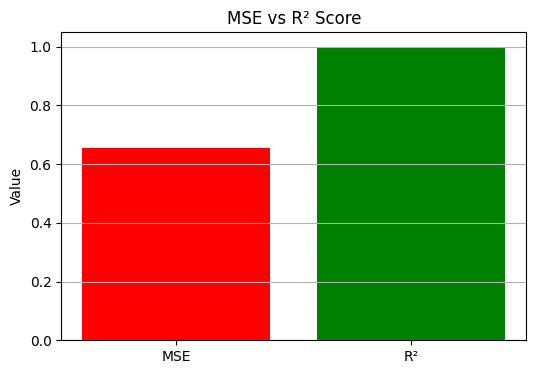

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.bar(['MSE', 'R²'], [mse, r2], color=['red', 'green'])

plt.title("MSE vs R² Score")
plt.ylabel("Value")
plt.grid(axis='y')

plt.show()